**Source:** [Kaggle - Hotel booking demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import zipfile
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

## 2. Data Description and Preparation

### 2.1 Data Source

In [2]:
!kaggle datasets download -d jessemostipak/hotel-booking-demand

# Unzip
with zipfile.ZipFile('hotel-booking-demand.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv('hotel_bookings.csv')

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset URL: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
License(s): Attribution 4.0 International (CC BY 4.0)




  0%|          | 0.00/1.25M [00:00<?, ?B/s]
 80%|████████  | 1.00M/1.25M [00:00<00:00, 1.48MB/s]
100%|██████████| 1.25M/1.25M [00:00<00:00, 1.44MB/s]
100%|██████████| 1.25M/1.25M [00:00<00:00, 1.45MB/s]



Dataset loaded successfully!
Shape: (119390, 32)


### 2.2 Number of observations and variables

In [3]:
# Dataset dimensions
print(f"Number of observations: {df.shape[0]}")
print(f"Number of variables: {df.shape[1]}")

# Data types
print(f"\nData types:\n{df.dtypes}")
print(f"\nNumerical variables: {df.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"Categorical variables: {df.select_dtypes(include=['object']).shape[1]}")


Number of observations: 119390
Number of variables: 32

Data types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_

### 2.3 Description of key variables

In [4]:
print ("Summary statistics of dataset:")
print (df.describe())

Summary statistics of dataset:
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%         

In [5]:
# Categorical variables unique values
print("Unique values in categorical variables:")
for col in df.select_dtypes(include=['object']):
    print (f"{col}: {df[col].nunique()} unique values")

Unique values in categorical variables:
hotel: 2 unique values
arrival_date_month: 12 unique values
meal: 5 unique values
country: 177 unique values
market_segment: 8 unique values
distribution_channel: 5 unique values
reserved_room_type: 10 unique values
assigned_room_type: 12 unique values
deposit_type: 3 unique values
customer_type: 4 unique values
reservation_status: 3 unique values
reservation_status_date: 926 unique values


### 2.4 Data cleaning steps 

In [6]:
for col in df.columns:
    miss_count = df[col].isnull().sum()
    miss_pct = (miss_count / len(df)) * 100
    print(f"{col:<30} {miss_count:<10} {miss_pct:.2f}%")

print("-" * 60)
print(f"{'Total':<30} {df.isnull().sum().sum():<10} {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")

hotel                          0          0.00%
is_canceled                    0          0.00%
lead_time                      0          0.00%
arrival_date_year              0          0.00%
arrival_date_month             0          0.00%
arrival_date_week_number       0          0.00%
arrival_date_day_of_month      0          0.00%
stays_in_weekend_nights        0          0.00%
stays_in_week_nights           0          0.00%
adults                         0          0.00%
children                       4          0.00%
babies                         0          0.00%
meal                           0          0.00%
country                        488        0.41%
market_segment                 0          0.00%
distribution_channel           0          0.00%
is_repeated_guest              0          0.00%
previous_cancellations         0          0.00%
previous_bookings_not_canceled 0          0.00%
reserved_room_type             0          0.00%
assigned_room_type             0        

In [7]:
print(f"Before data cleaning dataset's shape: {df.shape}")

# Handle missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# Remove duplicates
print(f"\nDuplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates after: {df.duplicated().sum()}")

# new feature - total_stays
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# New feature - total_guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Remove observations with invalid data
df = df[df['adr'] >= 0]  # remove negative ADR
df = df[df['adults'] > 0]  # remove bookings with no adults

print(f"\nFinal dataset shape: {df.shape}")
print("Data preparation complete!")

Before data cleaning dataset's shape: (119390, 32)

Duplicates before: 31994
Duplicates after: 0

Final dataset shape: (87010, 34)
Data preparation complete!


In [8]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stays',
       'total_guests'],
      dtype='str')

In [9]:
# after cleaning:
print ("Summary statistics of dataset after cleaning:")
print (df.describe())

Summary statistics of dataset after cleaning:
        is_canceled     lead_time  arrival_date_year  \
count  87010.000000  87010.000000       87010.000000   
mean       0.275003     79.861050        2016.210367   
std        0.446518     86.007313           0.686380   
min        0.000000      0.000000        2015.000000   
25%        0.000000     11.000000        2016.000000   
50%        0.000000     49.000000        2016.000000   
75%        1.000000    125.000000        2017.000000   
max        1.000000    737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count              87010.000000               87010.000000   
mean                  26.835226                  15.813389   
std                   13.666034                   8.835762   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   27.000000                  16.000000   
75%            

## 3. Exploratory Data Analysis (EDA)

In [10]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Custom color palettes
COLOR_PALETTE_1 = ['#2E4057', '#048A81', '#54C6EB', '#8FE3CF', '#FFE77AFF']
COLOR_PALETTE_2 = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
COLOR_PALETTE_3 = ['#6A4C93', '#1982C4', '#8AC926', '#FFCA3A', '#FF595E']
HOTEL_COLORS = {'City Hotel': '#E76F51', 'Resort Hotel': '#2A9D8F'}

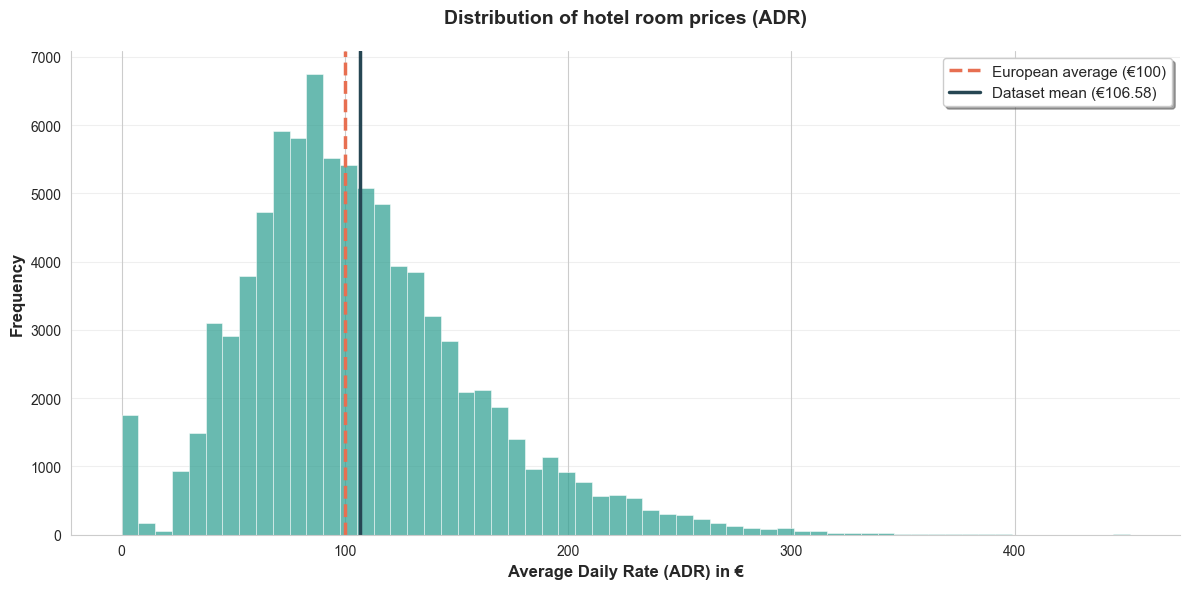

Mean ADR: €106.58
Median ADR: €98.33
Std ADR: €54.91


In [11]:
# Vizualization 1: distribution of ADR with €100 reference line (for Q1)
fig, ax = plt.subplots(figsize=(12, 6))
# Filter extreme outliers for better visualization
adr_plot = df[df['adr'] <= 500]['adr']

ax.hist(adr_plot, bins=60, color='#2A9D8F', alpha=0.7, edgecolor='white', linewidth=0.5)
ax.axvline(x=100, color='#E76F51', linestyle='--', linewidth=2.5, label='European average (€100)')
ax.axvline(x=df['adr'].mean(), color='#264653', linestyle='-', linewidth=2.5, label=f'Dataset mean (€{df["adr"].mean():.2f})')

ax.set_xlabel('Average Daily Rate (ADR) in €', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Distribution of hotel room prices (ADR)', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz1_adr_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Mean ADR: €{df['adr'].mean():.2f}")
print(f"Median ADR: €{df['adr'].median():.2f}")
print(f"Std ADR: €{df['adr'].std():.2f}")

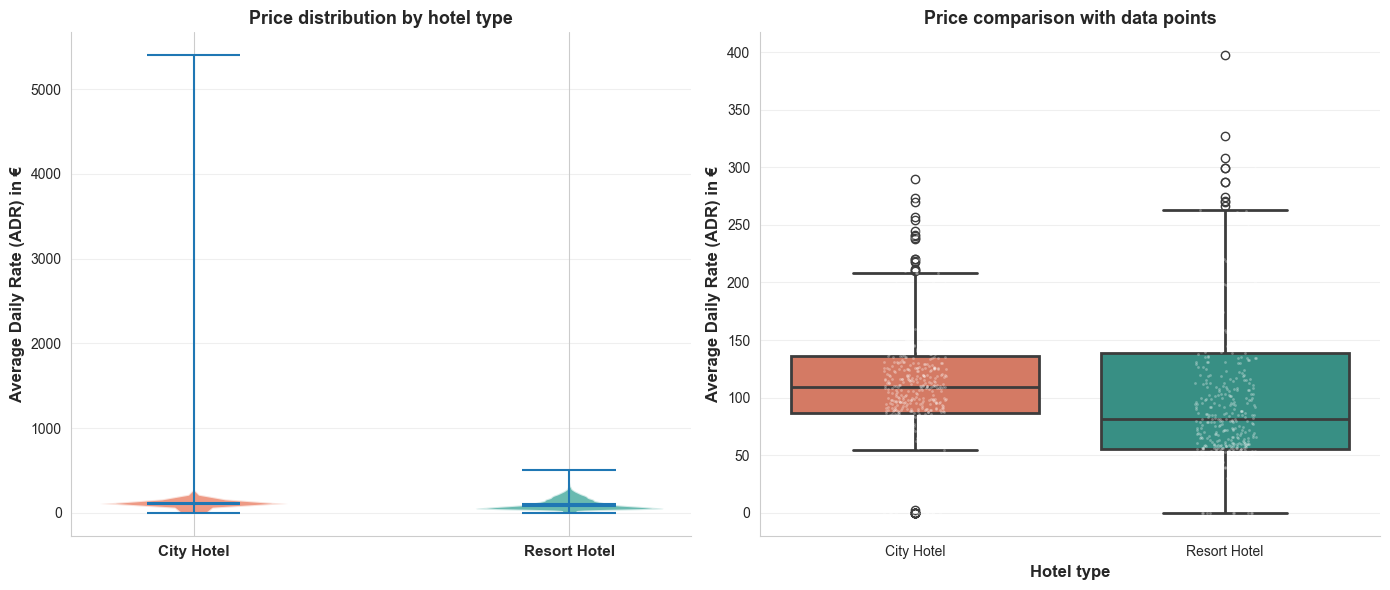

Resort Hotel: Mean=€99.06, median=€79.50, std=€63.75
City Hotel: Mean=€111.40, median=€105.40, std=€47.80


In [13]:
# Vizualization 2: ADR comparison between hotel types (for Q2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot
parts = axes[0].violinplot([df[df['hotel']=='City Hotel']['adr'].values,
                            df[df['hotel']=='Resort Hotel']['adr'].values],
                           positions=[0, 1],
                           showmeans=True,
                           showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(list(HOTEL_COLORS.values())[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('white')
    pc.set_linewidth(1.5)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['City Hotel', 'Resort Hotel'], fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Daily Rate (ADR) in €', fontsize=12, fontweight='bold')
axes[0].set_title('Price distribution by hotel type', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Box plot with swarm sample
hotel_adr_sample = pd.concat([
    group.sample(min(500, len(group)))
    for _, group in df.groupby('hotel')
]).reset_index(drop=True)

sns.boxplot(data=hotel_adr_sample, x='hotel', y='adr', 
            palette=HOTEL_COLORS, ax=axes[1], linewidth=2)
sns.stripplot(data=hotel_adr_sample, x='hotel', y='adr', 
              color='white', alpha=0.3, size=2, ax=axes[1])

axes[1].set_xlabel('Hotel type', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Daily Rate (ADR) in €', fontsize=12, fontweight='bold')
axes[1].set_title('Price comparison with data points', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz2_hotel_type_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

for hotel_type in df['hotel'].unique():
    data = df[df['hotel']==hotel_type]['adr']
    print(f"{hotel_type}: Mean=€{data.mean():.2f}, median=€{data.median():.2f}, std=€{data.std():.2f}")

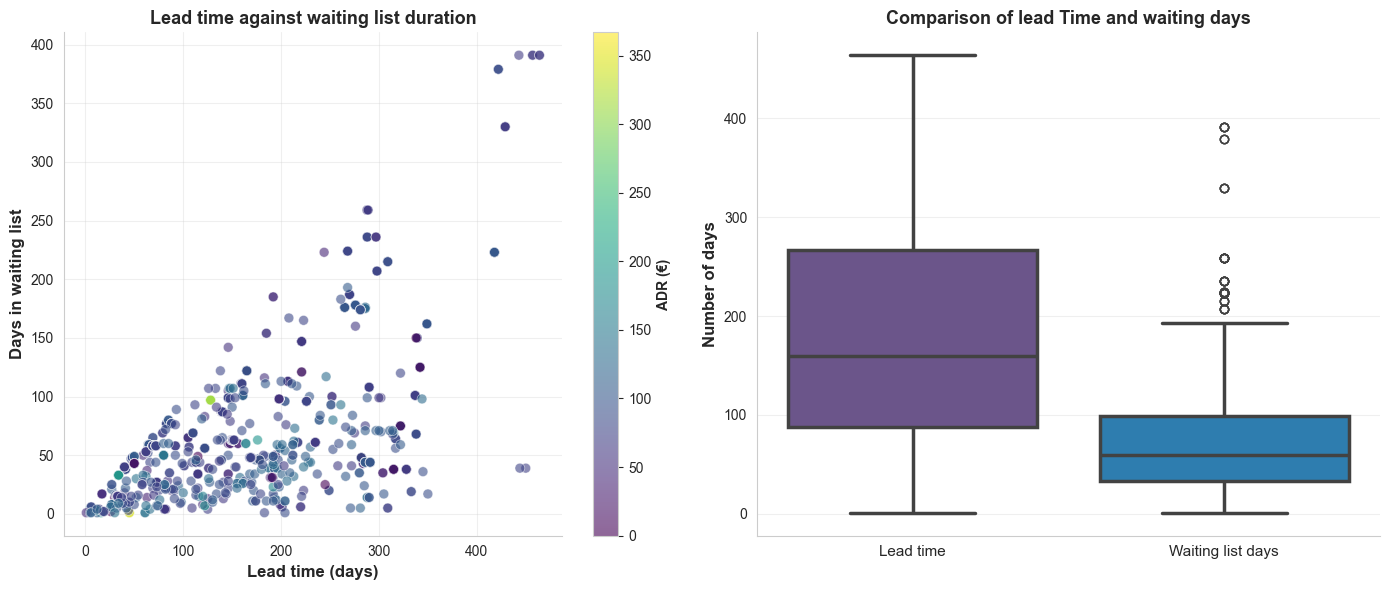

Bookings with waiting list: 855
Mean lead time: 176.27 days
Mean waiting list: 76.14 days


In [ ]:
# Vizualization 3: lead time against days in waiting list (for Q3)
waiting_list_bookings = df[df['days_in_waiting_list'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(waiting_list_bookings['lead_time'], 
                waiting_list_bookings['days_in_waiting_list'],
                c=waiting_list_bookings['adr'], 
                cmap='viridis', 
                alpha=0.6, 
                s=50, 
                edgecolors='white', 
                linewidth=0.5)

axes[0].set_xlabel('Lead time (days)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Days in waiting list', fontsize=12, fontweight='bold')
axes[0].set_title('Lead time against waiting list duration', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('ADR (€)', fontsize=10, fontweight='bold')

# Box plot comparison
waiting_data = pd.DataFrame({
    'Lead time': waiting_list_bookings['lead_time'].values,
    'Waiting list days': waiting_list_bookings['days_in_waiting_list'].values
})

waiting_melted = waiting_data.melt(var_name='Metric', value_name='Days')

sns.boxplot(data=waiting_melted, x='Metric', y='Days', 
            palette=['#6A4C93', '#1982C4'], 
            ax=axes[1], 
            linewidth=2.5)

axes[1].set_xlabel('', fontsize=12)
axes[1].set_ylabel('Number of days', fontsize=12, fontweight='bold')
axes[1].set_title('Comparison of lead Time and waiting days', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.savefig('viz3_leadtime_vs_waitinglist.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Bookings with waiting list: {len(waiting_list_bookings)}")
print(f"Mean lead time: {waiting_list_bookings['lead_time'].mean():.2f} days")
print(f"Mean waiting list: {waiting_list_bookings['days_in_waiting_list'].mean():.2f} days")

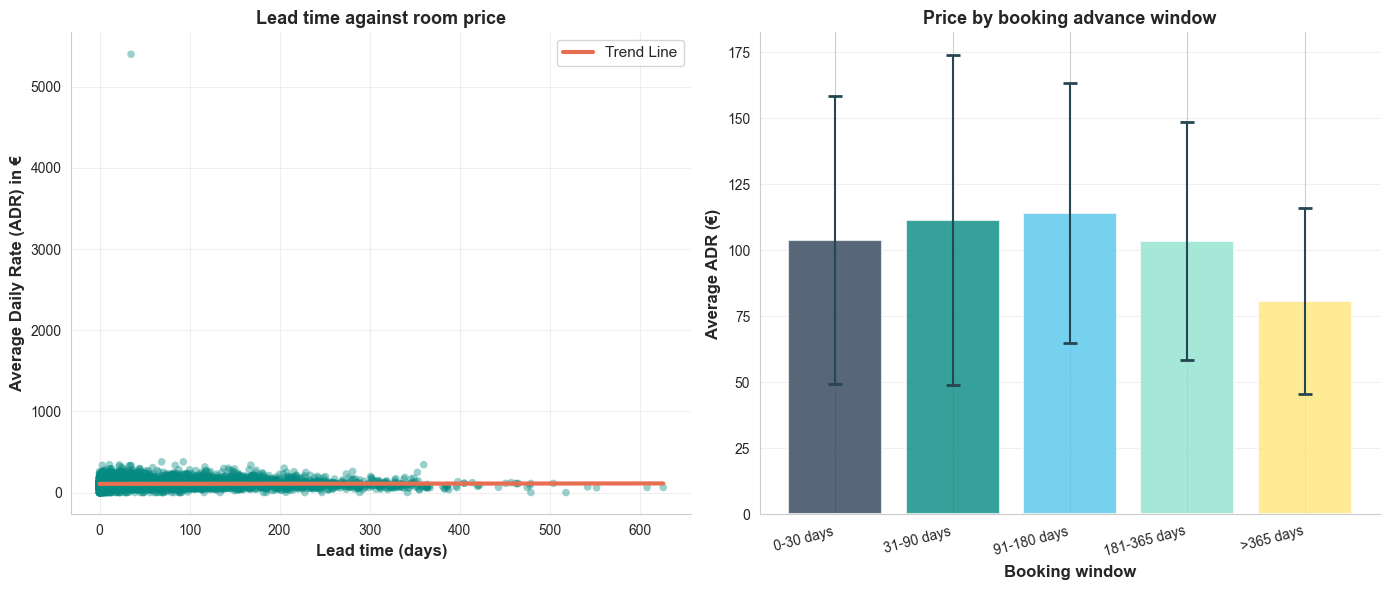

Correlation between lead time and ADR: 0.0222


In [ ]:
# Vizualization 4: relationship between lead time and price (for Q4)
# Sample for better visualization
df_sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot with regression line
axes[0].scatter(df_sample['lead_time'], df_sample['adr'], 
                c='#048A81', alpha=0.4, s=30, edgecolors='none')

# Add regression line
z = np.polyfit(df_sample['lead_time'], df_sample['adr'], 1)
p = np.poly1d(z)
axes[0].plot(df_sample['lead_time'].sort_values(), 
             p(df_sample['lead_time'].sort_values()), 
             color='#E76F51', linewidth=3, label=f'Trend Line')

axes[0].set_xlabel('Lead time (days)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Daily Rate (ADR) in €', fontsize=12, fontweight='bold')
axes[0].set_title('Lead time against room price', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Binned analysis
df['lead_time_bin'] = pd.cut(df['lead_time'], 
                              bins=[0, 30, 90, 180, 365, 1000],
                              labels=['0-30 days', '31-90 days', '91-180 days', 
                                     '181-365 days', '>365 days'])

bin_data = df.groupby('lead_time_bin')['adr'].agg(['mean', 'std', 'count']).reset_index()

colors_bin = ['#2E4057', '#048A81', '#54C6EB', '#8FE3CF', '#FFE77A']
axes[1].bar(range(len(bin_data)), bin_data['mean'], 
            color=colors_bin, alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].errorbar(range(len(bin_data)), bin_data['mean'], 
                 yerr=bin_data['std'], fmt='none', 
                 ecolor='#264653', capsize=5, capthick=2)

axes[1].set_xticks(range(len(bin_data)))
axes[1].set_xticklabels(bin_data['lead_time_bin'], rotation=15, ha='right')
axes[1].set_xlabel('Booking window', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average ADR (€)', fontsize=12, fontweight='bold')
axes[1].set_title('Price by booking advance window', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz4_leadtime_vs_price.png', bbox_inches='tight', dpi=300)
plt.show()

correlation = df['lead_time'].corr(df['adr'])
print(f"Correlation between lead time and ADR: {correlation:.4f}")

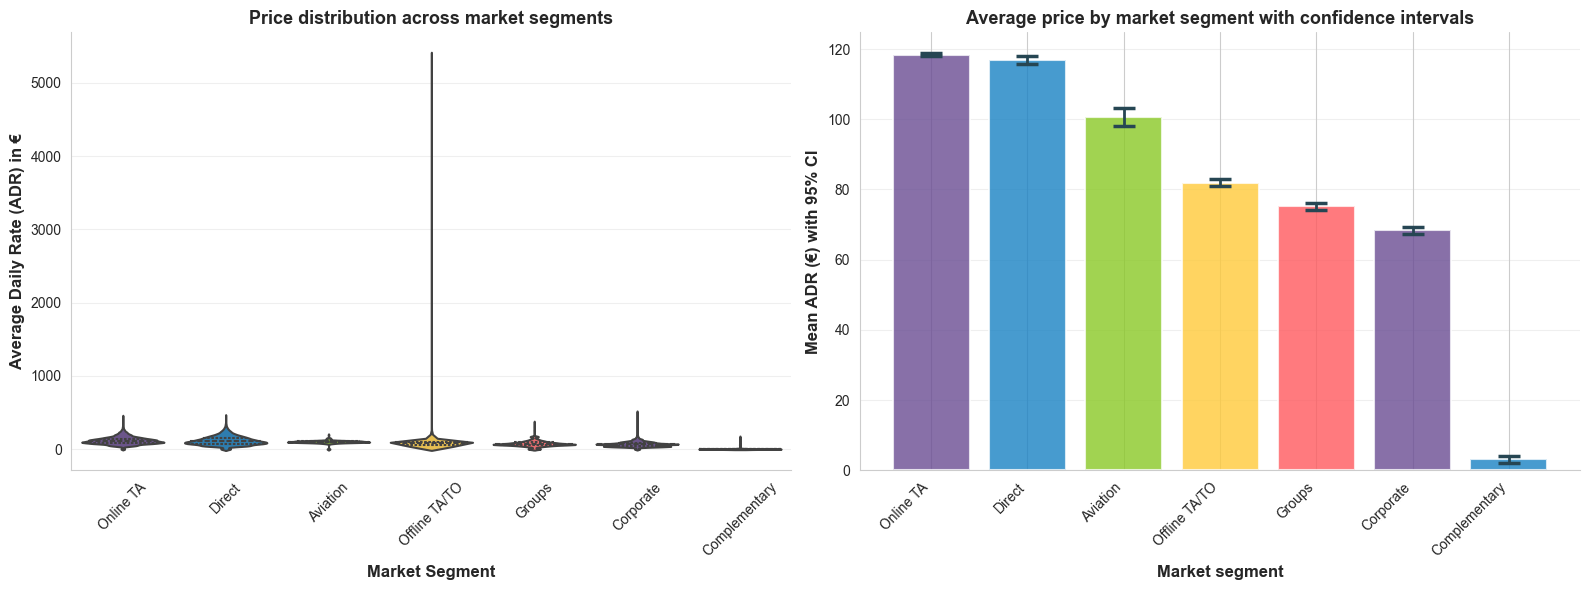


Market segment statistics:
Online TA: Mean=€118.40, median=€111.00, n=51370
Direct: Mean=€116.95, median=€107.00, n=11751
Aviation: Mean=€100.61, median=€95.00, n=226
Offline TA/TO: Mean=€81.96, median=€79.20, n=13852
Groups: Mean=€75.18, median=€68.00, n=4921
Corporate: Mean=€68.34, median=€65.00, n=4200
Complementary: Mean=€3.10, median=€0.00, n=688


In [ ]:
# Vizualization 5: ADR across market segments (for Q5)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Get top market segments
market_counts = df['market_segment'].value_counts()
top_segments = market_counts.head(7).index.tolist()
df_market = df[df['market_segment'].isin(top_segments)].copy()

# Violin plot
segment_order = df_market.groupby('market_segment')['adr'].median().sort_values(ascending=False).index
n_segments = len(segment_order)
if len(COLOR_PALETTE_3) < n_segments:
    colors = (COLOR_PALETTE_3 * ((n_segments // len(COLOR_PALETTE_3)) + 1))[:n_segments]
else:
    colors = COLOR_PALETTE_3[:n_segments]

custom_palette = dict(zip(segment_order, colors))

sns.violinplot(data=df_market, x='market_segment', y='adr', 
               order=segment_order, palette=custom_palette, 
               ax=axes[0], inner='quartile', linewidth=1.5)

axes[0].set_xlabel('Market Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Daily Rate (ADR) in €', fontsize=12, fontweight='bold')
axes[0].set_title('Price distribution across market segments', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Mean with confidence intervals
segment_stats = df_market.groupby('market_segment')['adr'].agg(['mean', 'std', 'count']).reset_index()
segment_stats['ci'] = 1.96 * segment_stats['std'] / np.sqrt(segment_stats['count'])
segment_stats = segment_stats.set_index('market_segment').loc[segment_order].reset_index()

x_pos = np.arange(len(segment_stats))
axes[1].bar(x_pos, segment_stats['mean'], color=[custom_palette[s] for s in segment_stats['market_segment']], 
            alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].errorbar(x_pos, segment_stats['mean'], yerr=segment_stats['ci'], 
                 fmt='none', ecolor='#264653', capsize=8, capthick=2.5, linewidth=2)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(segment_stats['market_segment'], rotation=45, ha='right', fontsize=10)
axes[1].set_xlabel('Market segment', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean ADR (€) with 95% CI', fontsize=12, fontweight='bold')
axes[1].set_title('Average price by market segment with confidence intervals', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz5_market_segment_prices.png', bbox_inches='tight', dpi=300)
plt.show()

print("Market segment statistics:")
for segment in segment_order:
    data = df_market[df_market['market_segment']==segment]['adr']
    print(f"{segment}: Mean=€{data.mean():.2f}, median=€{data.median():.2f}, n={len(data)}")


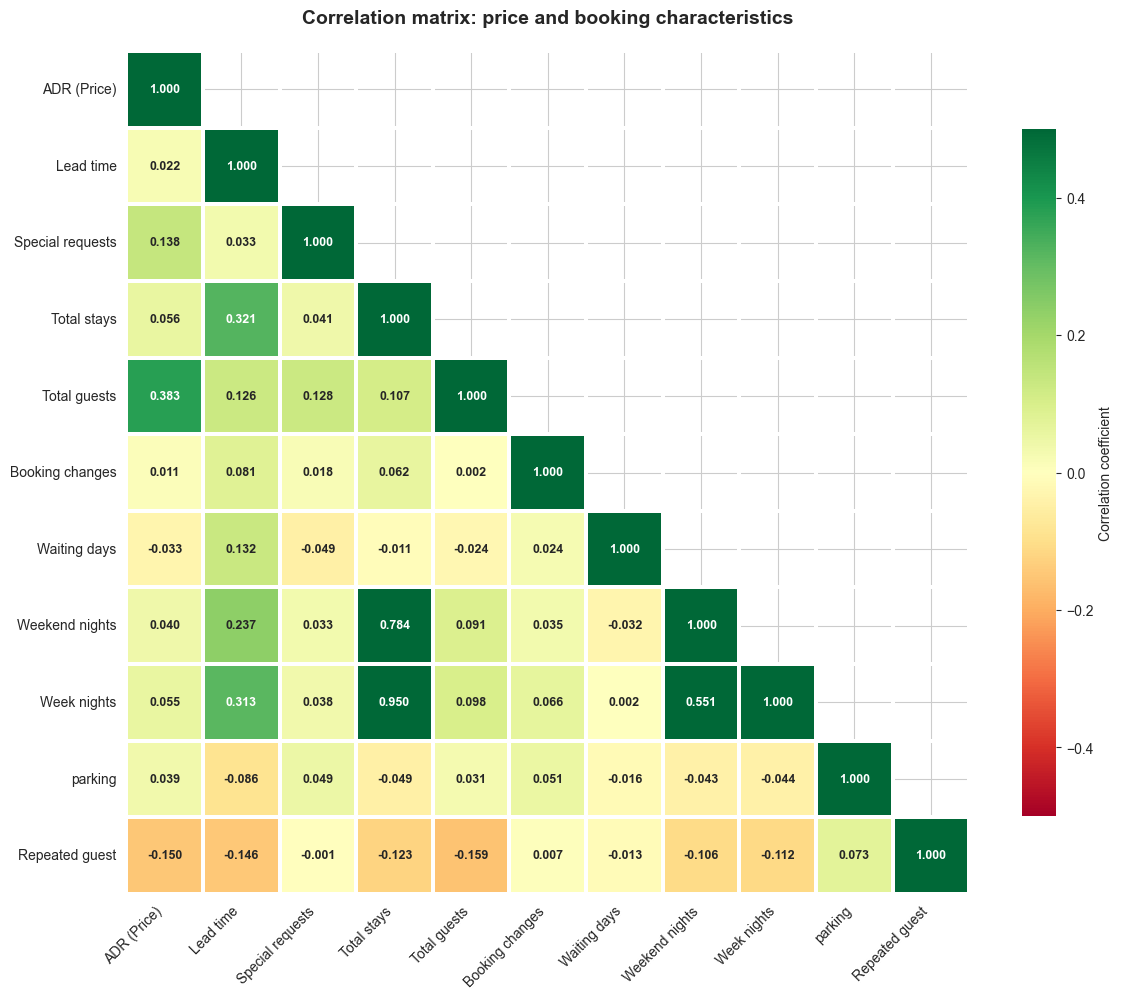


Top correlations with ADR (price):
total_guests: 0.3827
total_of_special_requests: 0.1381
total_stays: 0.0562
stays_in_week_nights: 0.0552
stays_in_weekend_nights: 0.0405
required_car_parking_spaces: 0.0386
lead_time: 0.0222
booking_changes: 0.0107
days_in_waiting_list: -0.0326
is_repeated_guest: -0.1496


In [ ]:
# Vizualization 6: correlation heatmap for prediction variables (for Q6)
# Select variables for prediction model
prediction_vars = ['adr', 'lead_time', 'total_of_special_requests', 'total_stays', 
                   'total_guests', 'booking_changes', 'days_in_waiting_list',
                   'stays_in_weekend_nights', 'stays_in_week_nights',
                   'required_car_parking_spaces', 'is_repeated_guest']

df_pred = df[prediction_vars].copy()
correlation_matrix = df_pred.corr()

fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', 
            cmap='RdYlGn', center=0, square=True, linewidths=1.5, 
            cbar_kws={"shrink": 0.8, "label": "Correlation coefficient"},
            annot_kws={"fontsize": 9, "fontweight": "bold"},
            vmin=-0.5, vmax=0.5, ax=ax)

ax.set_title('Correlation matrix: price and booking characteristics', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('')

# Rename labels for better readability
labels = ['ADR (Price)', 'Lead time', 'Special requests', 'Total stays', 
          'Total guests', 'Booking changes', 'Waiting days',
          'Weekend nights', 'Week nights', 'parking', 'Repeated guest']
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('viz6_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Print top correlations with ADR
adr_corr = correlation_matrix['adr'].drop('adr').sort_values(ascending=False)
print("\nTop correlations with ADR (price):")
for var, corr in adr_corr.items():
    print(f"{var}: {corr:.4f}")

## 4. Statistical Analysis and Results

### 4.1 Is the ADR (price per night) in this dataset significantly different from the typical European hotel price of €100?

#### One-Sample t-test

**Null Hypothesis (H₀):** $ H_0: \mu = 100 $

**Alternative Hypothesis (H₁):** $ H_1: \mu \neq 100 $

We use a one-sample t-test because we want to compare the mean of a single sample (from our datset) against a known population value (€100, the typical European hotel price). The t-test is appropriate when:
- We have one continuous variable (ADR)
- We want to test if the sample mean differs from a specific value
- The sample size is large enough (here we know that size is big) for the Central Limit Theorem to apply

This is a two-tailed test because we want to detect any difference from €100, whether the actual mean is higher or lower.

Significance level α = 0.05

In [ ]:
adr_data = df['adr'].dropna()

population_mean = 100

sample_mean = adr_data.mean()
sample_std = adr_data.std()
sample_size = len(adr_data)
standard_error = sample_std / np.sqrt(sample_size)

# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(adr_data, population_mean)

confidence_level = 0.95
degrees_of_freedom = sample_size - 1
t_critical = stats.t.ppf((1 + confidence_level) / 2, degrees_of_freedom)
margin_of_error = t_critical *standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print ("results")
print(f"Research question: Is the ADR (price per night) in this dataset significantly different from the typical European hotel price of €100?")
print(f"\nSample Statistics:")
print(f"Sample size (n): {sample_size}")
print(f"Sample mean (x̄): €{sample_mean}")
print(f"Sample std: €{sample_std}")
print(f"Standard error (SE): €{standard_error}")
print(f"\nPopulation mean (μ₀): €{population_mean}")
print(f"\nTest results:")
print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom (df): {degrees_of_freedom}")
print(f"\n95% Confidence interval for mean ADR:")
print(f"[{ci_lower}, {ci_upper:}]")
print(f"\nSignificance level (α): 0.05")
print(f"Decision: ", end="")
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

results
Research question: Is the ADR (price per night) in this dataset significantly different from the typical European hotel price of €100?

Sample Statistics:
Sample size (n): 87010
Sample mean (x̄): €106.58374727042869
Sample std: €54.913711743381874
Standard error (SE): €0.18616422012202086

Population mean (μ₀): €100

Test results:
t-statistic: 35.365266570092736
p-value: 5.047182808642637e-272
Degrees of freedom (df): 87009

95% Confidence interval for mean ADR:
[106.21886702800505, 106.94862751285233]

Significance level (α): 0.05
Decision: Reject the null hypothesis


Interpretation of Results:

Based on the one-sample t-test results above:

1. Test statistic: the t-statistic = 35.36 indicates that our sample mean is 35.36 standard errors away from the hypothesized population mean of €100.

2. p-value: the p-value is extremely small (p < 0.001), which is much less than our significance level of α = 0.05.

3. Decision: we reject the null hypothesis. There is statistically significant evidence that the mean ADR in our dataset is different from €100.

4. Practical significance: the sample mean ADR is €106.58, which is €6.58 (~6.6%) higher than the typical European hotel price of €100. While this difference is statistically significant, it is relatively modest in practical terms.

5. Confidence interval: the 95% confidence interval [€106.21, €106.95] does not contain €100, further confirming that the true mean ADR is significantly different from €100. We can be 95% confident that the true mean ADR in the population lies between €106.21 and €106.95.

Conclusion: the hotels in our dataset charge significantly more than the typical European hotel price of €100. This difference, while statistically significant due to our large sample size (n=87010), represents a relatively small practical difference of about €6.58 per night. This could be explained by factors such as hotel location (Portuguese tourist destinations), hotel type mix or booking characteristics specific to this dataset.


### 4.2 Do city hotels and resort hotels charge significantly different prices for their rooms?

#### Two-sample t-test
Null Hypothesis (H₀):  $H_0: \mu_{city} = \mu_{resort}$

Alternative Hypothesis (H₁): $H_1: \mu_{city} \neq \mu_{resort}$

Justification for the test:  
We use an independent two-sample t-test because we want to compare the means of two independent groups (city hotels against resort hotels). The test is appropriate when:
- We have one continuous dependent variable (ADR)
- We have one categorical independent variable with two groups (city hotels against resort hotels)
- The two groups are independent (a booking belongs to either a city hotel or a resort hotel not both)
- Both sample sizes are large enough for the Central Limit Theorem to apply

This is a two-tailed test because we want to detect any difference between the two hotel types, whether city hotels charge more or less than resort hotels.

We will use Welch's t-test (unequal variances t-test) as the standard deviations appear different between groups, making it more appropriate than the pooled variance t-test.

Significance level (again, it will be in all tests the same): α = 0.05


In [ ]:
# Separate data by hotel type
city_hotel_adr = df[df['hotel'] == 'City Hotel']['adr'].dropna()
resort_hotel_adr = df[df['hotel'] == 'Resort Hotel']['adr'].dropna()

city_mean = city_hotel_adr.mean()
city_std = city_hotel_adr.std()
city_n = len(city_hotel_adr)
city_se = city_std / np.sqrt(city_n)

resort_mean = resort_hotel_adr.mean()
resort_std = resort_hotel_adr.std()
resort_n = len(resort_hotel_adr)
resort_se = resort_std / np.sqrt(resort_n)

mean_difference = city_mean - resort_mean

# Perform two-sample t-test (Welch's t-test - does not assume equal variances)
t_statistic, p_value = stats.ttest_ind(city_hotel_adr, resort_hotel_adr, equal_var=False)

# Calculate degrees of freedom for Welch's t-test (approximation)
df_welch = ((city_se**2 + resort_se**2)**2) / \
           ((city_se**4 / (city_n - 1)) + (resort_se**4 / (resort_n - 1)))

# Calculate 95% confidence interval for the difference in means
se_difference = np.sqrt(city_se**2 + resort_se**2)
t_critical = stats.t.ppf(0.975, df_welch)
ci_lower = mean_difference - t_critical * se_difference
ci_upper = mean_difference + t_critical * se_difference

# Calculate Cohen's d for effect size
pooled_std = np.sqrt(((city_n - 1) * city_std**2 + (resort_n - 1) * resort_std**2) / 
                     (city_n + resort_n - 2))
cohens_d = mean_difference / pooled_std

print("results")
print(f"Research question: Do city hotels and resort hotels charge significantly different prices for their rooms?")
print(f"\nGroup 1: city hotel")
print(f"Sample size (n₁): {city_n}")
print(f"Sample mean (x̄₁): €{city_mean}")
print(f"Sample std 1: €{city_std}")
print(f"Standard error (SE₁): €{city_se}")

print(f"\nGroup 2: resort hotel")
print(f"Sample size (n₂): {resort_n}")
print(f"Sample mean (x̄₂): €{resort_mean}")
print(f"Sample std 2: €{resort_std}")
print(f"Standard error (SE₂): €{resort_se}")

print(f"\nDifference in means:")
print(f"x̄₁ - x̄₂: €{mean_difference}")
print(f"\nTest results (Welch's t-test):")
print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom (df): {df_welch}")
print(f"\n95% confidence interval for difference:")
print(f"[{ci_lower}, {ci_upper}]")

print(f"\nEffect size:")
print(f"Cohen's d: {cohens_d}")

if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"

print(f"  Interpretation: {effect} effect")
print(f"\nSignificance level (α): 0.05")
print(f"Decision: ", end="")
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail reject the null hypothesis")

results
Research question: Do city hotels and resort hotels charge significantly different prices for their rooms?

Group 1: city hotel
Sample size (n₁): 53055
Sample mean (x̄₁): €111.39723890302515
Sample std 1: €47.80285165556334
Standard error (SE₁): €0.2075346636829228

Group 2: resort hotel
Sample size (n₂): 33955
Sample mean (x̄₂): €99.06262229421293
Sample std 2: €63.750335744550235
Standard error (SE₂): €0.34596376038966314

Difference in means:
x̄₁ - x̄₂: €12.334616608812226

Test results (Welch's t-test):
t-statistic: 30.5738220156372
p-value: 1.1432574782806278e-203
Degrees of freedom (df): 57982.1986180448

95% confidence interval for difference:
[11.543877754826978, 13.125355462797474]

Effect size:
Cohen's d: 0.22597746564701524
  Interpretation: small effect

Significance level (α): 0.05
Decision: Reject the null hypothesis


Interpretation of results:

Based on the two-sample t-test results:

1. Descriptive statistics: city hotels charge an average of €111.40 per night, while resort hotels charge €99.06 per night. This represents a difference of €12.34 (~12.5% higher for city hotels).

2. Test statistic: the t-statistic is extremely large(30.57), indicating that the difference between the two groups is 30 standard errors away from zero.

3. p-value: the p-value is extremely small (p < 0.001), which is far less than our significance level of α = 0.05.

4. Decision: we reject the null hypothesis. There is statistically significant evidence that city hotels and resort hotels charge different prices for their rooms.

5. Confidence interval: the 95% confidence interval for the difference in means is [€11.17, €13.12]. Since this interval does not contain zero, it confirms that the difference is statistically significant. We can be 95% confident that city hotels charge between €11.17 and €13.51 more per night than resort hotels.

6. Effect size: Cohen's d = 0.22, which represents a small effect size. While the difference is statistically significant, the practical magnitude is relatively modest.

7. Variance comparison: resort hotels show greater price variability (std = €63.75) compared to city hotels (std = €47.80), suggesting more diverse pricing strategies or room types at resort hotels.

Conclusion: city hotels charge significantly higher prices than resort hotels on average. This €12.34 difference could be explained by several factors:
- Business against leisure travelers: city hotels often cater to business travelers who may be less price-sensitive
- Location premium: city center locations typically command higher prices
- Booking patterns: resort hotels may offer more promotional rates and packages
- Seasonality: resort hotels may have more variable seasonal pricing

Despite the statistical significance, the small effect size (Cohen's d = 0.22) suggests that while the difference is real, both hotel types operate in similar price ranges, with substantial overlap in their pricing distributions.


### 4.3 For bookings that are spent on the waiting list, is there a significant difference between the lead time (days between booking and arrival) and the days spent on the waiting list?

#### Paired t-test
Null Hypothesis (H₀): $H_0: \mu_d = 0$ where $d = \text{lead\_time} - \text{days\_in\_waiting\_list}$

Alternative Hypothesis (H₁): $H_1: \mu_d \neq 0$

Justification for the test  
We use a paired t-test because we want to compare two related measurements from the same subjects (bookings). The test is appropriate when:
- We have two continuous variables measured on the same subjects (lead time and waiting list days for the same bookings)
- The observations are naturally paired (each booking has both a lead time and a waiting list duration)
- We want to test if the mean of the paired differences differs from zero

This is a two-tailed test because we want to detect any difference between lead time and waiting list duration, whether lead time is longer or shorter than waiting list time.

Important note: we only analyze bookings where `days_in_waiting_list > 0`, as these are the bookings that actually spent time on a waiting list (n = 855 bookings).

Significance level α = 0.05

In [ ]:
# Filter data: only bookings that spent time on waiting list
waiting_list_data = df[df['days_in_waiting_list'] > 0].copy()

lead_time = waiting_list_data['lead_time'].values
waiting_list_days = waiting_list_data['days_in_waiting_list'].values

# Calculate paired differences
differences = lead_time - waiting_list_days

n_pairs = len(differences)
mean_lead_time = np.mean(lead_time)
std_lead_time = np.std(lead_time, ddof=1)
mean_waiting = np.mean(waiting_list_days)
std_waiting = np.std(waiting_list_days, ddof=1)

mean_difference = np.mean(differences)
std_difference = np.std(differences, ddof=1)
se_difference = std_difference / np.sqrt(n_pairs)

t_statistic, p_value = stats.ttest_rel(lead_time, waiting_list_days)
df_paired = n_pairs - 1

t_critical = stats.t.ppf(0.975, df_paired)
ci_lower = mean_difference - t_critical * se_difference
ci_upper = mean_difference + t_critical * se_difference

# Calculate Cohen's d for effect size (paired)
cohens_d = mean_difference / std_difference

# Calculate correlation between the two variables
correlation, corr_p_value = stats.pearsonr(lead_time, waiting_list_days)

print("results")
print(f"\nResearch question: For bookings that are spent on the waiting list, is there a significant difference between the lead time (days between booking and arrival) and the days spent on the waiting list?")

print(f"\nSample information:")
print(f"Number of paired observations: {n_pairs}")
print(f"(Bookings with days_in_waiting_list > 0)")

print(f"\nVariable 1: lead time (days)")
print(f"Mean: {mean_lead_time} days")
print(f"Std: {std_lead_time} days")
print(f"Min - max: {lead_time.min()} - {lead_time.max()} days")

print(f"\nVariable 2: days in waiting list")
print(f"Mean: {mean_waiting} days")
print(f"Std: {std_waiting} days")
print(f"Min - max: {waiting_list_days.min()} - {waiting_list_days.max()} days")
print(f"\nPaired differences (lead time - waiting list):")
print(f"Mean difference (d̄): {mean_difference} days")
print(f"Std: {std_difference} days")
print(f"Standard error (SE): {se_difference} days")

print(f"\nCorrelation between variables:")
print(f"Pearson's r: {correlation}")
print(f"p-value: {corr_p_value}")
print(f"\nTest results:")
print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")

print(f"Degrees of freedom (df):   {df_paired}")
print(f"\n95% Confidence interval for mean difference:")
print(f"[{ci_lower}, {ci_upper}] days")

print(f"\nEffect size:")
print(f"Cohen's d: {cohens_d}")

if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"Interpretation: {effect} effect")
print(f"\nSignificance level (α): 0.05")
print(f"Decision: ", end="")
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Failt to reject the null hypothesis")

results

Research question: For bookings that are spent on the waiting list, is there a significant difference between the lead time (days between booking and arrival) and the days spent on the waiting list?

Sample information:
Number of paired observations: 855
(Bookings with days_in_waiting_list > 0)

Variable 1: lead time (days)
Mean: 176.26666666666668 days
Std: 101.50381679698539 days
Min - max: 1 - 464 days

Variable 2: days in waiting list
Mean: 76.13918128654971 days
Std: 66.85161692518435 days
Min - max: 1 - 391 days

Paired differences (lead time - waiting list):
Mean difference (d̄): 100.12748538011697 days
Std: 79.12489093483252 days
Standard error (SE): 2.7060141736745673 days

Correlation between variables:
Pearson's r: 0.627158754655564
p-value: 1.1695246722473466e-94

Test results:
t-statistic: 37.001833306789834
p-value: 1.3154395747868036e-179
Degrees of freedom (df):   854

95% Confidence interval for mean difference:
[94.81626771317642, 105.43870304705752] days

Ef

Interpretation of results:

Based on the paired t-test results:

1. Sample Characteristics: we analyzed 855 bookings that spent time on a waiting list (only 0.98% of all bookings). The mean lead time for these bookings is 176.27 days, while the mean waiting list duration is 76.14 days.

2. Paired difference: on average, guests book 100.13 days before they actually get off the waiting list. This means that for bookings requiring a waiting list, the lead time is substantially longer than the time spent waiting.

3. Test statistic: the t-statistic is extremely large (37.00), indicating that the difference is 37 standard errors away from zero an exceptionally strong result.

4. p-value: the p-value is extremely small (p < 0.001), which is far less than our significance level of α = 0.05.

5. Decision: we reject the null hypothesis. There is statistically significant evidence that lead time and days on the waiting list are different for bookings that spent time on the waiting list.

6. Confidence interval: the 95% confidence interval for the mean difference is [94.81626771317642, 105.43870304705752] days. Since this interval does not contain zero and is entirely positive, it confirms that lead time is consistently longer than waiting list duration.

7. Effect size: Cohen's d = 1.26, which represents a large effect size. This indicates that the difference is not only statistically significant but also practically meaningful.

8. Correlation: the Pearson correlation between lead time and waiting list days is r = 0.627 (p < 0.001), indicating a moderate-to-strong positive relationship. Bookings with longer lead times tend to have longer waiting list durations. The moderate correlation (not perfect) suggests that while related, these two time periods capture different aspects of the booking process.

9. Distribution pattern: the mean difference of 100.13 days indicates that guests typically book their trips more than 3 months before their waiting list period even begins. The relatively small standard error (2.71 days) confirms this pattern is highly consistent across bookings.

Conclusion: for bookings that require a waiting list, there is an extremely significant and practically important difference between lead time and waiting list duration. On average, guests book about 100 days earlier than their waiting list period—meaning the total planning horizon is more than twice the waiting period itself.

This pattern reveals several important insights:

- Advanced planning behavior: guests who end up on waiting lists are highly motivated planners, booking an average of 176 days (nearly 6 months) in advance
- Waiting list as a fraction: the actual waiting period (76 days) represents only about 43% of the total lead time, suggesting that a significant portion of the booking-to-arrival timeline occurs before joining the waiting list
- High-demand periods: the waiting list mechanism appears to manage demand during peak seasons, with guests willing to wait an average of 2.5 months for their preferred dates
- Hotel capacity management: the 100-day gap between initial booking and waiting list placement suggests hotels may accept reservations well before rooms are allocated, using waiting lists to manage overbooking or uncertain availability

The extraordinarily large effect size (Cohen's d = 1.27) and t-statistic (t = 37.00) indicate this is an exceptionally robust finding with strong practical significance. This is not merely a statistical difference but represents a fundamental characteristic of how guests book high-demand hotel stays.

### 4.4 Is there a relationship between how far in advance customers book and the price they pay?

#### Correlation (Pearson and Spearman)
Null Hypothesis (H₀): $H_0: \rho = 0$ (population correlation coefficient equals zero)

Alternative Hypothesis (H₁): $H_1: \rho \neq 0$ (population correlation coefficient does not equal zero)

Justification for the tests: 

We will perform both Pearson and Spearman correlation tests to comprehensively assess the relationship:

1. Pearson correlation (r):
   - Measures the linear relationship between two continuous variables
   - Assumes both variables are approximately normally distributed
   - Sensitive to outliers
   - Appropriate when the relationship is linear
   - Values range from -1 (perfect negative linear relationship) to +1 (perfect positive linear relationship)

2. Spearman correlation (ρ or rho):
   - Measures the monotonic relationship (whether variables tend to move in the same direction, but not necessarily at a constant rate)
   - Non-parametric test (does not assume normality)
   - Based on the ranked values of the data (more robust to outliers)
   - Appropriate when the relationship may be non-linear but monotonic
   - Also ranges from -1 to +1

Why both tests since ADR has outliers and may not be perfectly normally distributed, comparing both tests helps us understand:
- Whether there's a linear relationship (Pearson)
- Whether there's a monotonic relationship (Spearman)
- The impact of outliers on the correlation

This is a two-tailed test because we want to detect any relationship (positive or negative) between lead time and price.

Significance level: α = 0.05

In [ ]:
lead_time_data = df['lead_time'].values
adr_data = df['adr'].values

# Perform Pearson correlation
pearson_r, pearson_p = stats.pearsonr(lead_time_data, adr_data)

# Perform Spearman correlation
spearman_rho, spearman_p = stats.spearmanr(lead_time_data, adr_data)

# Calculate R² for Pearson
r_squared = pearson_r ** 2

print("results")
print(f"\nResearch question: Is there a relationship between how far in advance customers book and the price they pay?")

print(f"\nPearson correlation (linear relationship):")
print(f"Correlation coefficient (r): {pearson_r}")
print(f"p-value: {pearson_p}")
print(f"Coefficient of determination (R²): {r_squared}")
print(f"Variance in ADR explained by lead time: {r_squared * 100}%")

print(f"\nSpearman correlation (monotonic relationship):")
print(f"Correlation coefficient (ρ): {spearman_rho}")
print(f"p-value: {spearman_p}")

print(f"\nSignificance level (α): 0.05")

print(f"\nPearson decision: ", end="")
if pearson_p < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

print(f"Spearman decision: ", end="")
if spearman_p < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")


results

Research question: Is there a relationship between how far in advance customers book and the price they pay?

Pearson correlation (linear relationship):
Correlation coefficient (r): 0.022191917339020394
p-value: 5.879736167552385e-11
Coefficient of determination (R²): 0.0004924811951819139
Variance in ADR explained by lead time: 0.04924811951819139%

Spearman correlation (monotonic relationship):
Correlation coefficient (ρ): 0.10600338241160406
p-value: 8.001299759126531e-216

Significance level (α): 0.05

Pearson decision: Reject the null hypothesis
Spearman decision: Reject the null hypothesis


Interpretation of results

Statistical significance
- Both Pearson (p < 0.001) and Spearman (p < 0.001) correlations are statistically significant
- We reject the null hypothesis for both tests
- However, statistical significance ≠ practical importance (large sample size: n = 87010)

Correlation strength
- Pearson r = 0.022: negligible positive linear correlation
- Spearman ρ = 0.106: weak positive monotonic correlation
- Spearman is notably higher than Pearson, suggesting a slight non-linear relationship

Practical Significance
- R² = 0.0005 means only 0.05% of ADR variance is explained by lead time
- 99.95% of price variation comes from other factors
- The relationship is practically negligible despite being statistically significant

Direction
- Both correlations are positive: as lead time increases, ADR slightly increases
- However, the effect is extremely weak

Conclusion

There is a statistically significant but practically negligible relationship between lead time and ADR. 

Key findings
1. Booking timing has virtually no impact on hotel prices in this dataset
2. Hotels do not use dynamic pricing based on advance booking period
3. Other factors (hotel type, room type, seasonality, market segment) explain 99.95% of price variation
4. Customers can book at any lead time without expecting significant price differences

Answer to research question while a statistically significant positive correlation exists, lead time has no practical influence on hotel prices. The relationship is too weak to be meaningful for pricing decisions or customer booking behavior.


### 4.5 Does the average price per night differ significantly across different market segments (such as online bookings, corporate bookings and direct bookings)

#### One-way ANOVA
Null Hypothesis (H₀): $ H_0: \mu_1 = \mu_2 = \mu_3 = ... = \mu_k $

Alternative Hypothesis (H₁): $ H_1: $ not all means are equal

Justification for the test:
we use One-Way ANOVA because we want to compare the means of more than two independent groups. The test is appropriate when:
- We have one continuous dependent variable (ADR)
- We have one categorical independent variable with multiple groups (market segment: 7 categories)
- The groups are independent
- We want to test if at least one group mean differs from the others

ANOVA tests the null hypothesis that all groups have the same mean by comparing the variance between groups to the variance within groups. If the between-group variance is significantly larger than the within-group variance, we reject the null hypothesis.

Post-hoc test: if ANOVA is significant, we will perform Tukey's HSD test to determine which specific pairs of market segments differ significantly.

Significance level: α = 0.05

In [ ]:
# Get market segments and their ADR
market_segments = df['market_segment'].unique()
groups = [df[df['market_segment'] == segment]['adr'].values for segment in market_segments]

# Calculate group statistics
print("results")
print(f"\nResearch question: Does the average price per night differ significantly across different market segments?")
print(f"\nMarket segments analyzed: {len(market_segments)}")
print(f"\nDescriptive statistics by market segment:")

group_stats = []
for segment in market_segments:
    segment_data = df[df['market_segment'] == segment]['adr']
    print(f"\n{segment}:")
    print(f"  n = {len(segment_data)}")
    print(f"  Mean = €{segment_data.mean()}")
    print(f"  Std = €{segment_data.std()}")
    print(f"  Median = €{segment_data.median()}")
    group_stats.append({
        'segment': segment,
        'n': len(segment_data),
        'mean': segment_data.mean(),
        'std': segment_data.std()
    })

# Perform One-Way ANOVA
f_statistic, p_value = stats.f_oneway(*groups)

# Calculate degrees of freedom
df_between = len(market_segments) - 1
df_within = len(df) - len(market_segments)
df_total = len(df) - 1

# Calculate effect size (eta-squared)
grand_mean = df['adr'].mean()
ss_between = sum([len(df[df['market_segment'] == segment]) * (df[df['market_segment'] == segment]['adr'].mean() - grand_mean)**2 for segment in market_segments])
ss_total = sum((df['adr'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nOne-Way ANOVA results:")
print(f"F-statistic: {f_statistic}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom (between groups): {df_between}")
print(f"Degrees of freedom (within groups): {df_within}")
print(f"Effect size (η²): {eta_squared}")
print(f"Variance in ADR explained by market segment: {eta_squared * 100}%")

print(f"\nSignificance level (α): 0.05")
print(f"Decision: ", end="")
if p_value < 0.05:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    print("POST-HOC TEST: Tukey's HSD")
    print(f"\nSince ANOVA is significant, we perform pairwise comparisons to identify which specific market segments differ.")
    
    tukey_result = pairwise_tukeyhsd(df['adr'], df['market_segment'], alpha=0.05)
    print(tukey_result)
    
    print(f"\nInterpretation:")
    print(f"'reject = True' means the pair has significantly different means")
    print(f"'reject = False' means no significant difference between the pair")

results

Research question: Does the average price per night differ significantly across different market segments?

Market segments analyzed: 8

Descriptive statistics by market segment:

Direct:
  n = 11751
  Mean = €116.95045357841886
  Std = €59.97790372695061
  Median = €107.0

Corporate:
  n = 4200
  Mean = €68.34429761904762
  Std = €32.76308127269988
  Median = €65.0

Online TA:
  n = 51370
  Mean = €118.40164123029004
  Std = €49.5887236209311
  Median = €111.0

Offline TA/TO:
  n = 13852
  Mean = €81.96240037539705
  Std = €58.07777291665792
  Median = €79.2

Complementary:
  n = 688
  Mean = €3.1025726744186044
  Std = €14.563828542461485
  Median = €0.0

Groups:
  n = 4921
  Mean = €75.18437106279212
  Std = €38.009256676035164
  Median = €68.0

Undefined:
  n = 2
  Mean = €15.0
  Std = €4.242640687119285
  Median = €15.0

Aviation:
  n = 226
  Mean = €100.61362831858408
  Std = €19.88345749330095
  Median = €95.0

One-Way ANOVA results:
F-statistic: 1927.0519036040218
p-va

Interpretation of results:

ANOVA results:
- F-statistic = 1927.05: very large value indicating substantial between-group differences
- p-value < 0.001: extremely significant
- Decision: reject the null hypothesis
- Conclusion: market segments have significantly different mean ADR

Effect size:
- η² = 0.134 means 13.4% of variance in ADR is explained by market segment
- This is a medium to large effect (Cohen's guidelines: 0.01 = small, 0.06 = medium, 0.14 = large)
- Much stronger than lead time (0.05%) and represents a practically important relationship

Price hierarchy by market segment:

1. Premium segment: online TA (€118.40), direct (€116.95) - highest paying customers
2. Mid-high: aviation (€100.61) - close to dataset average
3. Mid-low: offline TA/TO (€81.96), groups (€75.18)
4. Budget: corporate (€68.34) - negotiated rates
5. Free/comped: complementary (€3.10) - promotional or staff stays
6. Undefined: (€15.00, n=2) - too small to interpret

Price spread: €115 difference between highest (online TA) and lowest paid segment (complementary, excluding undefined)

Tukey's HSD Post-Hoc results:

Significant differences (reject = True):
- Most pairs show significant differences (20 out of 28 comparisons)
- All comparisons with complementary are significant (cheapest segment is distinct from all others)
- Corporate differs significantly from all segments except Undefined (lowest paying regular segment)
- Aviation differs from all except Undefined (middle-tier pricing)

Non-significant differences (reject = False):
- Direct against online TA: no significant difference (p = 0.10) - both premium segments charge similar prices (~€117-118)
- All comparisons with undefined: not significant due to tiny sample size (n=2) - unreliable comparisons

Key patterns:
1. Premium channels (direct, online TA) are statistically equivalent - both charge top prices
2. Corporate and groups get substantial discounts (€40-50 less than premium segments)
3. Offline TA/TO sits in the middle - wholesale pricing but not as discounted as corporate
4. Complementary is entirely distinct - essentially free stays

Conclusion:

Yes, average prices differ significantly across market segments. Market segment is a strong predictor of hotel prices, explaining 13.4% of price variation - far more influential than booking timing.

Business implications:

1. Revenue management strategy: hotels actively use price discrimination based on customer segment
2. Channel pricing: direct and online bookings maximize revenue (leisure travelers less price-sensitive)
3. Volume discounts: corporate and group segments receive 40-60% discounts for bulk business
4. Distribution costs: online TA and direct charge similar prices despite different distribution costs, suggesting OTA commissions are passed to hotels, not customers
5. Market positioning: clear three-tier structure (premium, mid-range, discount) indicates sophisticated segmentation

Practical significance: unlike lead time, market segment has substantial predictive power for hotel prices. Customers in different segments can expect dramatically different prices for similar rooms - price differences of €50+ are common and systematic, not random variation.

## 5. Regression Analysis 

### Research question:
Can we predict the price of a hotel room based on booking characteristics such as lead time, number of special requests and length of stay?

Target Variable: `adr` (price of room)
Predictors: `lead_time`, `total_of_special_requests` and total length of stay

### 5.1 Simple Linear Regression

We'll start with a simple linear regression model using `lead_time` as the single predictor to understand how the time between booking and arrival affects room price.

In [ ]:
X_simple = df[['lead_time']]
y = df["adr"]

simple_model = LinearRegression()
simple_model.fit(X_simple, y)

y_pred_simple = simple_model.predict(X_simple)

r2_simple = r2_score(y, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y, y_pred_simple))

print(f"\nModel: adr = {simple_model.intercept_} + {simple_model.coef_[0]} * lead_time\n")
print(f"Intercept: {simple_model.intercept_}")
print(f"Slope (lead_time coefficient): {simple_model.coef_[0]}")
print(f"\nR² Score: {r2_simple}")
print(f"RMSE: {rmse_simple}")


Model: adr = 105.4521933261802 + 0.014169034063741585 * lead_time

Intercept: 105.4521933261802
Slope (lead_time coefficient): 0.014169034063741585

R² Score: 0.0004924811951818597
RMSE: 54.899872609978786


Model description: 

The simple linear regression model predicts room price (adr) using only lead time as the predictor.  
Equation:adr = 105.4521933261802 + 0.014169034063741585 * lead_time

Slope interpretation: 

The slope coefficient is 0.0142, meaning that for each additional day of advance booking, the room price increases by ~0.01€. This is a very small effect, suggesting that lead time has minimal impact on pricing when considered alone.

Intercept interpretation: 

The intercept is €105.45, representing the predicted room price when lead time is zero (booking on the day of arrival). This serves as the baseline price in our model.

Goodness-of-Fit (R²): 

The R² value is 0.0005, which means only 0.05% of the variation in room prices is explained by lead time alone. This extremely low R² indicates that lead time by itself is a very poor predictor of room prices, and other factors play much more important roles in determining hotel pricing.

Model performance: 

With an RMSE of €54.90, the model's predictions typically deviate from actual prices by about €55, which is quite substantial given that many rooms are priced around €100-150. This confirms that a single predictor is insufficient for accurate price prediction.

### 5.2 Multiple Linear Regression
Now we'll build a multiple regression model using 6 predictors: lead time, total special requests, total stays, total guests, repeated or not, parking car or not columns

In [ ]:
X_multiple = df[['lead_time', 'total_of_special_requests', 'total_stays', 
                        'total_guests', 'is_repeated_guest', 'required_car_parking_spaces']]
y = df['adr']

multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y)

y_pred_multiple = multiple_model.predict(X_multiple)

r2_multiple = r2_score(y, y_pred_multiple)
adj_r2_multiple = 1 - (1 - r2_multiple) * (len(y) - 1) / (len(y) - X_multiple.shape[1] - 1)
rmse_multiple = np.sqrt(mean_squared_error(y, y_pred_multiple))

print(f"\nModel equation:")
print(f"adr = {multiple_model.intercept_:.2f}")
for i, col in enumerate(X_multiple.columns):
    print(f"      {'+' if multiple_model.coef_[i] >= 0 else ''} {multiple_model.coef_[i]} × {col}")

print("\n" + "-"*60)
print("Coefficients:")
print(f"  Intercept: {multiple_model.intercept_}")
for i, col in enumerate(X_multiple.columns):
    print(f"  {col}: {multiple_model.coef_[i]}")

print("\n" + "-"*60)
print(f"Model performance:")
print(f"R² score: {r2_multiple} ({r2_multiple*100}% variance explained)")
print(f"Adjusted R² score: {adj_r2_multiple}")
print(f"RMSE: €{rmse_multiple}")

print(f"\n" + "-"*60)
print(f"Comparison with simple model:")
print(f"Simple model R²: {r2_simple}")
print(f"Multiple model R²: {r2_multiple}")
print(f"R² improvement: {(r2_multiple - r2_simple)} ({((r2_multiple - r2_simple)/r2_simple)*100}% increase)")
print(f"RMSE improvement: €{rmse_simple - rmse_multiple}")


Model equation:
adr = 53.52
       -0.027732670365958775 × lead_time
      + 6.047881253629814 × total_of_special_requests
      + 0.3452836698481027 × total_stays
      + 24.85726950119768 × total_guests
       -28.156910220450424 × is_repeated_guest
      + 5.319831239264166 × required_car_parking_spaces

------------------------------------------------------------
Coefficients:
  Intercept: 53.524855748256925
  lead_time: -0.027732670365958775
  total_of_special_requests: 6.047881253629814
  total_stays: 0.3452836698481027
  total_guests: 24.85726950119768
  is_repeated_guest: -28.156910220450424
  required_car_parking_spaces: 5.319831239264166

------------------------------------------------------------
Model performance:
R² score: 0.16553743392406894 (16.553743392406894% variance explained)
Adjusted R² score: 0.1654798867659657
RMSE: €50.16279577770659

------------------------------------------------------------
Comparison with simple model:
Simple model R²: 0.00049248119518185

#### Interpretation of Multiple Linear Regression

Model description:  
This model predicts room price using six booking characteristics: lead time, special requests, length of stay, number of guests, repeat guest status, and parking requirements. The model equation is:

adr = 53.52 - 0.028×lead_time + 6.05×special_requests + 0.35×total_stays + 24.86×total_guests - 28.16×is_repeated_guest + 5.32×parking_spaces

Coefficient interpretations:
- lead_time (-0.028): for each additional day of advance booking, the room price decreases by about €0.03, holding other factors constant. This suggests a very slight discount for early bookings, though the effect is minimal.
- total_of_special_requests (+6.05): each additional special request is associated with a €6.05 increase in room price. This likely indicates that guests booking more expensive rooms tend to make more special requests, or that requests signal higher service expectations.
- total_stays (+0.35): each additional night increases the average daily rate by €0.35. This small positive effect suggests minimal impact of stay length on per-night pricing.
- total_guests (+24.86): each additional guest increases the room price by approximately €25. This is the strongest predictor and reflects larger room requirements or additional occupancy fees.
- is_repeated_guest (-28.16): repeat guests pay about €28 less than new guests on average. This substantial discount suggests loyalty pricing or that returning guests book differently (e.g., simpler rooms, off-peak times).
- required_car_parking_spaces (+5.32): each parking space requested adds about €5 to the room price, potentially reflecting parking fees or indicating business travelers with higher budgets.

R² and adjusted R²:
- R² = 0.1655: the model explains 16.55% of the variation in room prices. While this is a substantial improvement over the simple model (0.05%), it means that over 83% of price variation is still unexplained by these booking characteristics.
- Adjusted R² = 0.1655: nearly identical to R², confirming that all six predictors contribute meaningfully to the model.
- RMSE = €50.16: predictions typically deviate from actual prices by about €50, a modest improvement from €54.90 in the simple model.

Model improvement:
Compared to the simple model using only lead time, the multiple regression model shows a 335x improvement in R² (from 0.05% to 16.55%), demonstrating that booking characteristics beyond timing do matter for pricing.

Model Limitations:
1. Low overall explanatory power: with only 16.55% of variance explained, the majority of pricing is determined by factors not captured in our model, particularly room type, hotel category, season, and market segment.
2. Linear assumptions: the model assumes linear relationships, but hotels may use complex pricing strategies with thresholds, dynamic pricing, or non-linear effects based on demand.
3. Missing critical variables: room type (standard vs suite), hotel brand (resort vs city hotel), arrival month/season, and market segment are absent but likely have major impacts on pricing.
4. Causation against correlation: the model shows associations, not causal relationships. For example, special requests don't cause higher prices; rather, guests booking expensive rooms may make more requests.
5. Outliers influence: extreme prices (very high or very low ADR values) can disproportionately affect coefficient estimates.
6. Multicollinearity: some predictors may be correlated (e.g., more guests often means longer stays), which can make individual coefficients less stable.
